# tmp — feb25

**Motivation**: scratch notebook <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-25/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-25/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-25/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import  plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from main.distributions import Poisson


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

In [3]:
cm = 'non-whitened'
model_name = 'gaussian_relu_vH16_t-16_z-[512]_cl-5,5_<grad|lin>'
fit_name = 'b200-ep300-lr(0.002)_beta(16:0.1)_gr(500)_(2025_02_24,21:34)'

tr, meta = load_model(f"{model_name}/{cm}_{fit_name}", device)

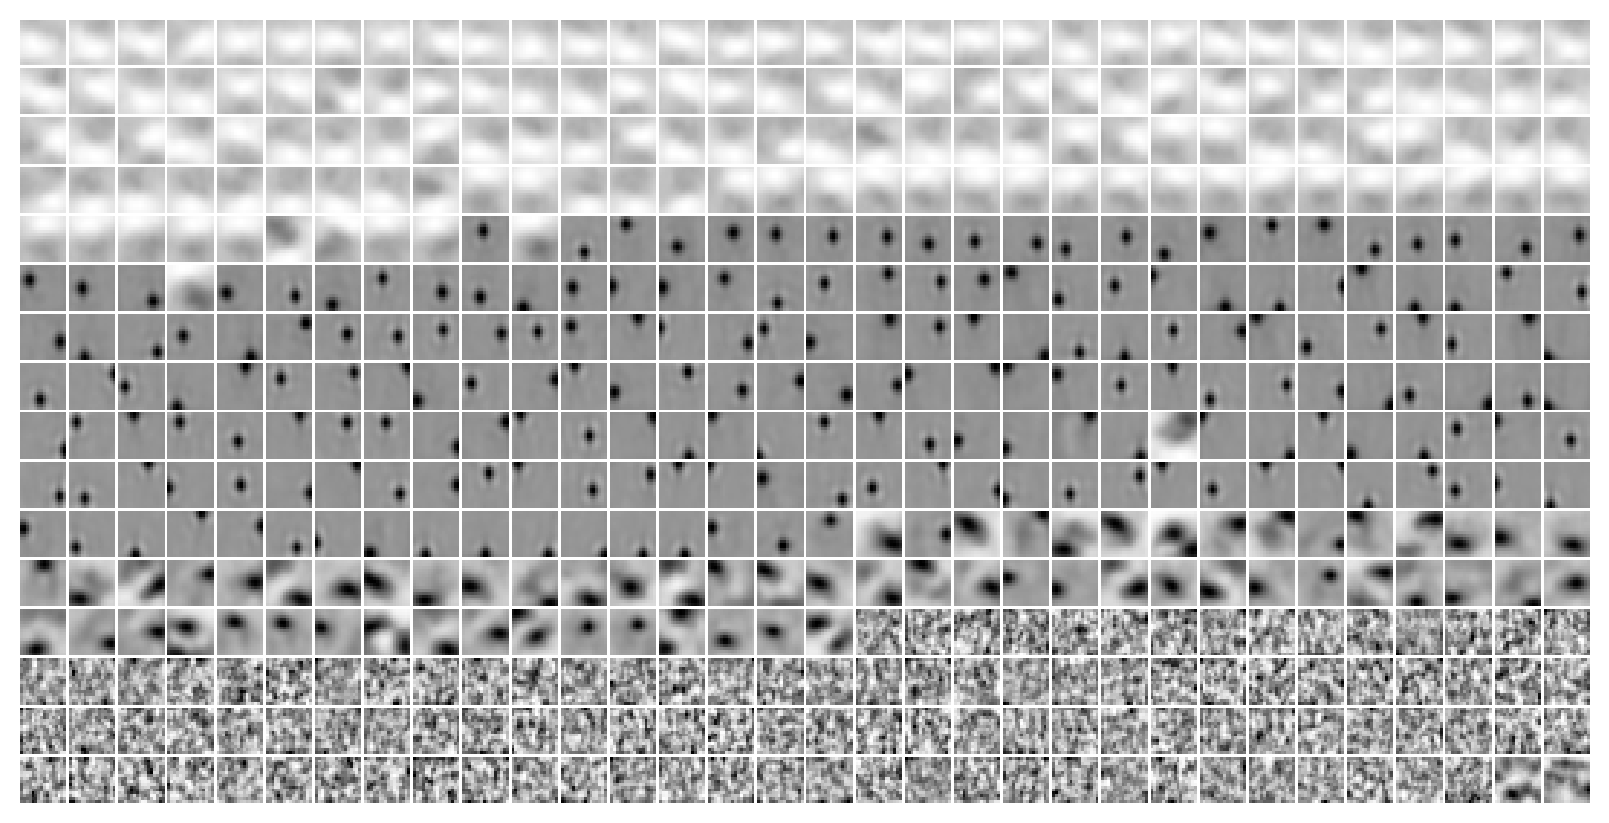

In [4]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u1 = tonp(tr.model.layer.u_init[1].squeeze())
tr.model.show(order=np.argsort(u1), method='abs-max', cmap='Greys');

In [9]:
w = tr.model.layer.get_weight().T
absmax = torch.max(w.abs(), dim=1, keepdims=True).values
# absmax = w.abs().max()
w_rescaled = 0.5 * (w / absmax + 1)
w_rescaled = w_rescaled.reshape(-1, 16, 16)

w_rescaled.shape

torch.Size([512, 16, 16])

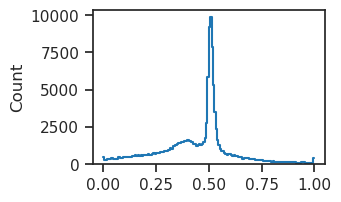

In [10]:
histplot(w_rescaled.ravel());

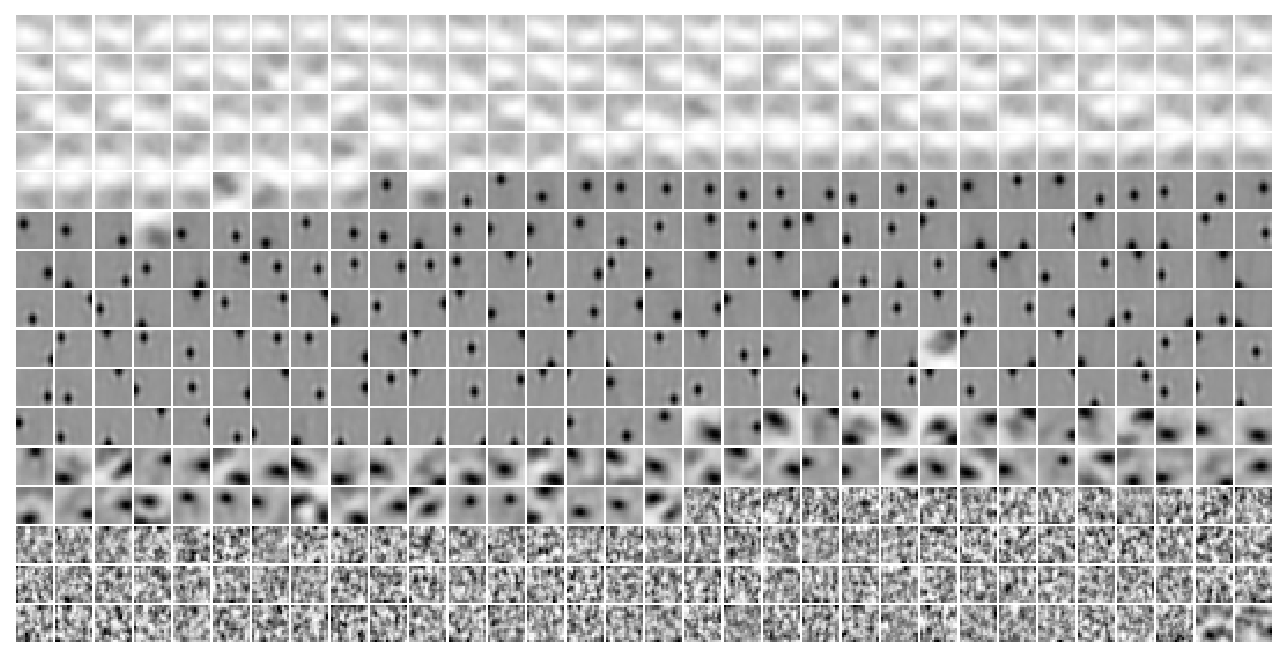

In [11]:
plot_weights(
    w=w_rescaled[np.argsort(u1)],
    method='none',
    vmin=0,
    vmax=1,
    cmap='Greys',
);

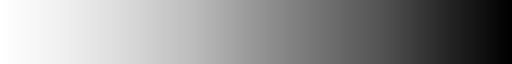

In [27]:
sns.color_palette('Greys', as_cmap=True)

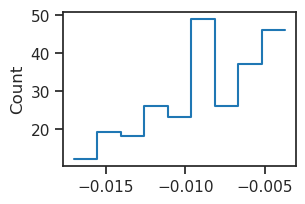

In [35]:
histplot(w[np.argsort(u1)][0].ravel());

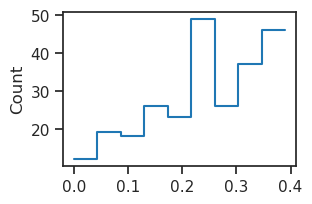

In [36]:
histplot(w_rescaled[np.argsort(u1)][0].ravel());

In [56]:
def rescale_weights(weights, axis=1):
    """
    Rescale weights so that 0 maps to 0.5 and the range [-max, max] is mapped to [0, 1].
    weights : np.ndarray of shape (K, M) (or any shape)
    axis    : axis along which to compute the maximum absolute value (default: 1)
    """

    w = tonp(weights)
    
    # Compute maximum absolute value along the specified axis
    max_abs = np.max(np.abs(w), axis=axis, keepdims=True)
    
    # Avoid division by zero: if max_abs is zero, set it to 1 so that weights remain zero.
    max_abs[max_abs == 0] = 1
    
    # Apply the rescaling transformation
    w_rescaled = 0.5 * (w / max_abs + 1)

    return w_rescaled

In [57]:
w = tr.model.layer.get_weight().T
w_rescaled = rescale_weights(w)
w_rescaled = w_rescaled.reshape(-1, 16, 16)

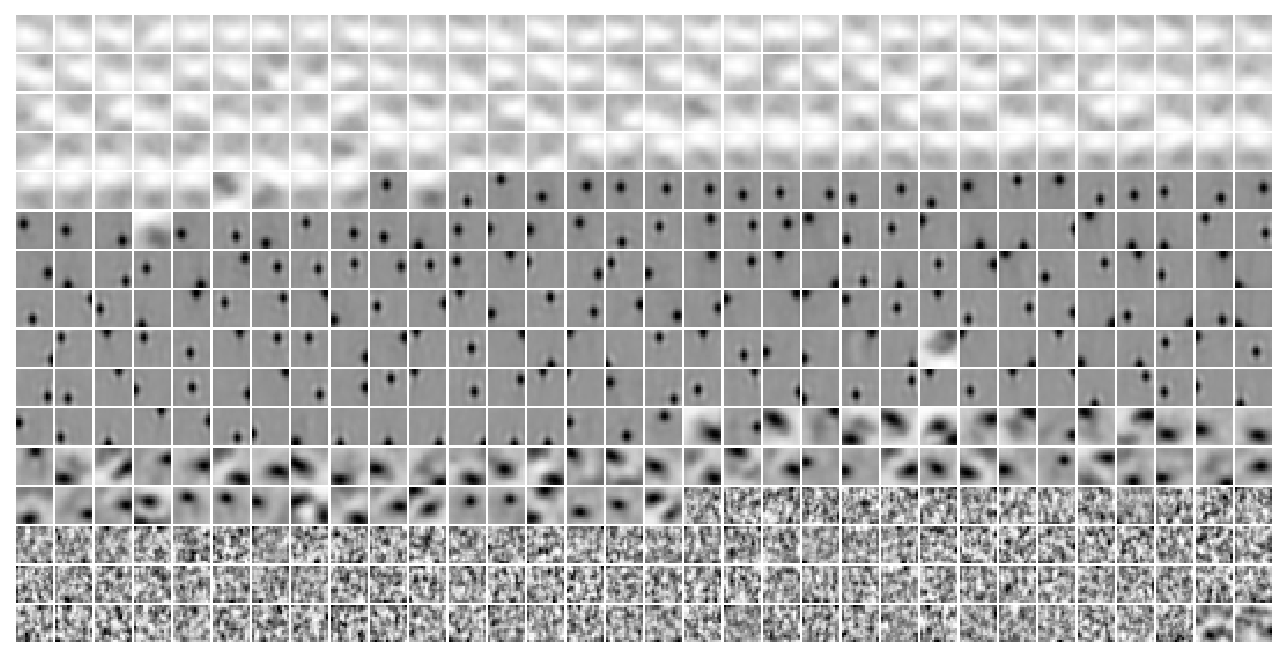

In [58]:
plot_weights(
    w=w_rescaled[np.argsort(u1)],
    method='none',
    vmin=0,
    vmax=1,
    cmap='Greys',
);

In [5]:
from main.distributions import softclamp_sym

In [13]:
x = torch.linspace(-20, 20, 1000)
c = 5

x_clamped = softclamp_sym(x, c)
sigma = torch.exp(x_clamped)

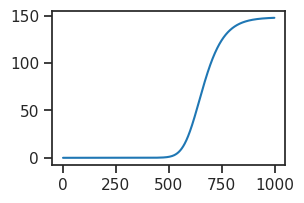

In [14]:
plot(sigma)

In [23]:
np.exp(-4.6), np.exp(4.6)

(0.010051835744633586, 99.48431564193378)

In [3]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs(model_type, 'vH16', 'grad|lin')

cfg_vae['seq_len'] = 8
cfg_vae['tbptt_steps'] = -1
cfg_vae['n_iters_inner'] = 1

# cfg_vae['fit_prior'] = False
cfg_vae['track_stats'] = True

cfg_tr['kl_beta'] = 8.0
cfg_tr['epochs'] = 300

mod = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
self = tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

In [ ]:
tr.train()

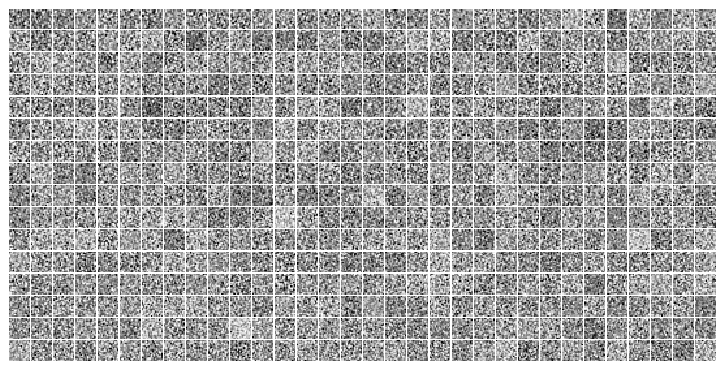

In [9]:
self.figs_to_writer(123, None)['phi']

In [9]:
lamb = torch.tensor([1.0, 5.0, 10.0], device=device)

pois = Poisson(
    log_rate=torch.log(lamb),
    temp=0.5,
    n_exp='infer',
)

In [10]:
pois.mean

tensor([ 1.0000,  5.0000, 10.0000], device='cuda:0')

In [11]:
pois.n_exp

21

In [12]:
samples = []
rsamples = []
for _ in tqdm(range(100000)):
    samples.append(pois.sample())
    rsamples.append(pois.rsample())

samples = torch.stack(samples).T
rsamples = torch.stack(rsamples).T

samples.shape, rsamples.shape

100%|████████████████████████████████| 100000/100000 [00:07<00:00, 13726.51it/s]


(torch.Size([3, 100000]), torch.Size([3, 100000]))

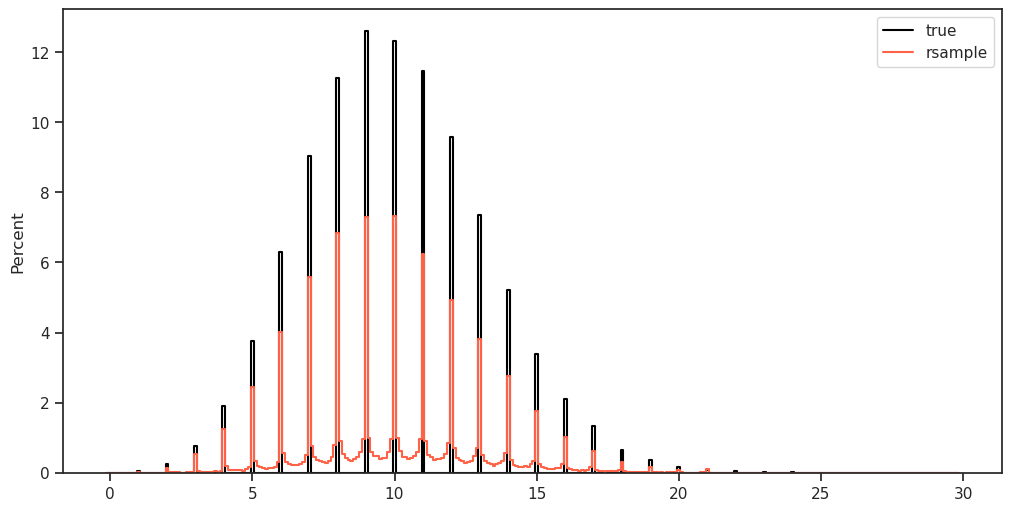

In [8]:
i = 2

bins = [
    np.linspace(0, 10, 101) - 0.15,
    np.linspace(0, 20, 201) - 0.15,
    np.linspace(0, 30, 301) - 0.15,
]

fig, ax = create_figure(1, 1, (10, 5))
histplot(samples[i], color='k', label='true', bins=bins[i], stat='percent')
histplot(rsamples[i], color='tomato', label='rsample', bins=bins[i], stat='percent')
plt.legend()
plt.show()

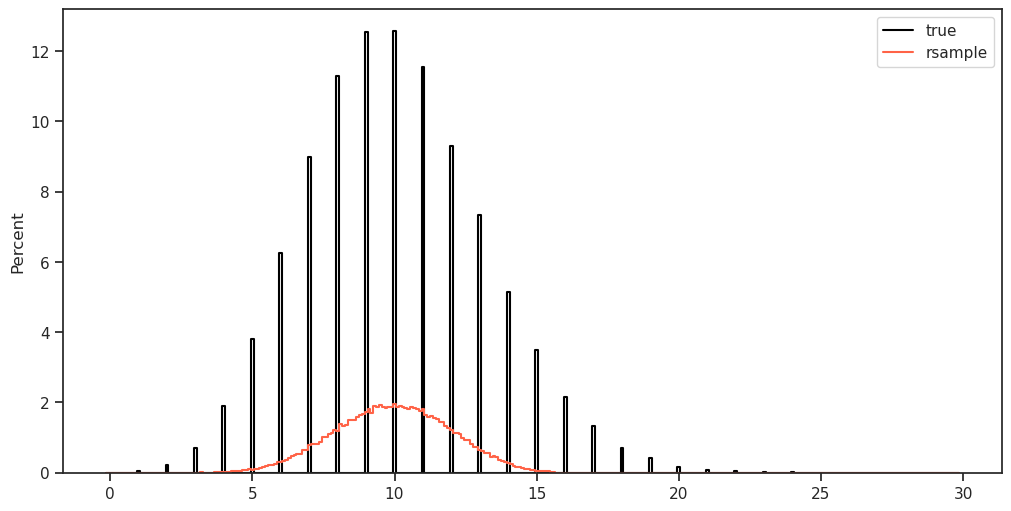

In [16]:
i = 2

bins = [
    np.linspace(0, 10, 101) - 0.15,
    np.linspace(0, 20, 201) - 0.15,
    np.linspace(0, 30, 301) - 0.15,
]

fig, ax = create_figure(1, 1, (10, 5))
histplot(samples[i], color='k', label='true', bins=bins[i], stat='percent')
histplot(rsamples[i], color='tomato', label='rsample', bins=bins[i], stat='percent')
plt.legend()
plt.show()

In [4]:
mod.cfg.clamp_du, mod.cfg.clamp_u

(7.0, 8.0)

In [5]:
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")

vH16_t-16_z-[512]_<grad|lin>
b200-ep300-lr(0.002)_beta(20:0.1)_temp(0.05:0.5)_gr(200)_(2025_02_14,23:58)

In [6]:
print(mod.cfg.sequences)

{0: range(0, 16)}

In [7]:
cm = f"reproduce-with-tbptt-option-disabled"
tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

# tr.train()

epoch # 300, avg loss: 269.862115: 100%|████| 300/300 [3:19:42<00:00, 39.94s/it]


epoch # 300, avg loss: 269.844871: 100%|████| 300/300 [3:13:58<00:00, 38.79s/it]


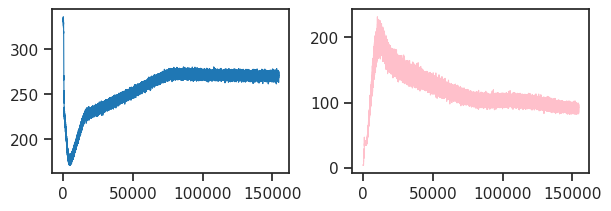

In [8]:
fig, axes = create_figure(1, 2)
axes[0].plot(list(tr.stats['loss'].values()), lw=0.8,)
axes[1].plot(list(tr.stats['grad'].values()), lw=0.8, color='pink');

In [9]:
u_min = np.asarray(tr.model.stats['u_min'])
u_max = np.asarray(tr.model.stats['u_max'])
du_min = np.asarray(tr.model.stats['du_min'])
du_max = np.asarray(tr.model.stats['du_max'])

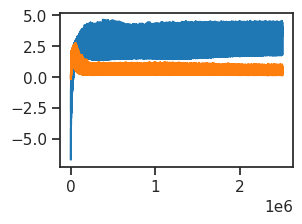

In [10]:
plt.plot(u_max);
plt.plot(du_max);

In [11]:
tr.model.cfg.clamp_u, tr.model.cfg.clamp_du

(8.0, 7.0)

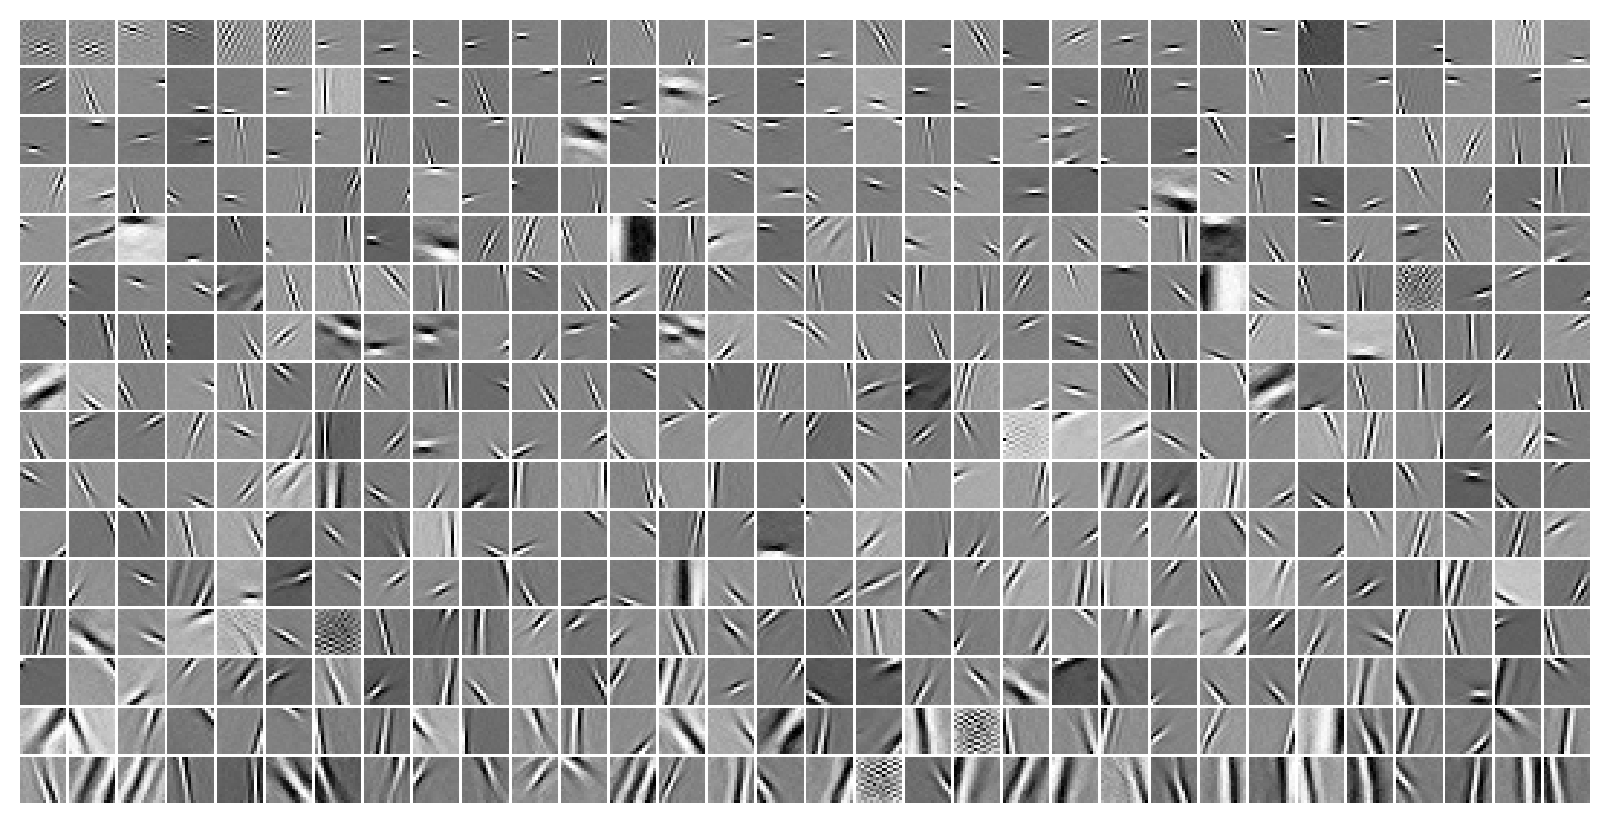

In [12]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

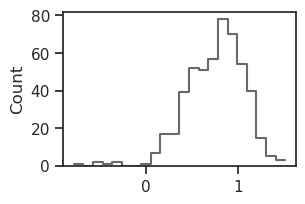

In [13]:
histplot(u0, color='dimgray');

100%|███████████████████████████████████| 2/2 [00:59<00:00, 29.65s/it]


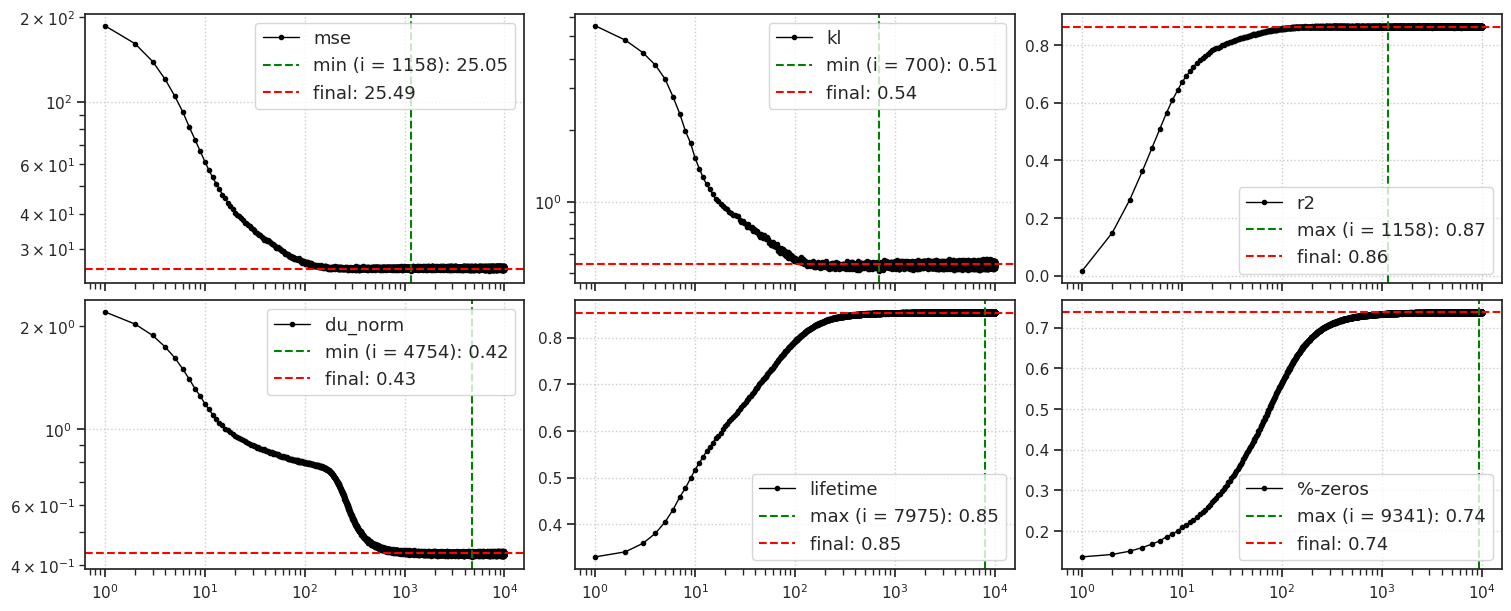

CPU times: user 1min 9s, sys: 5.93 s, total: 1min 15s
Wall time: 1min 15s


In [14]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [15]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

print(list(output))

['loss_kl', 'loss_recon', 'posterior', 'du', 'u', 'v', 'recon', 'samples', 'conditional', 'mse', 'r2']

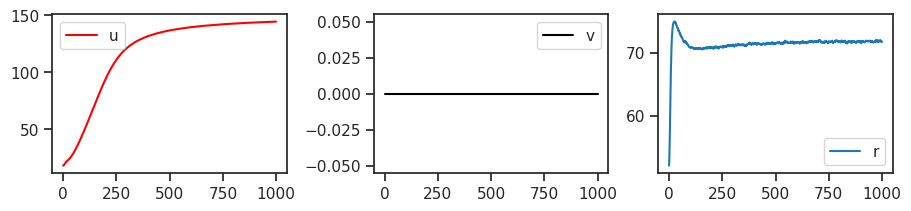

In [16]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

In [3]:
s = 'vH16_t-16_z-[512]_<grad|lin>/b200-ep300-lr(0.002)_beta(20:0.1)_temp(0.05:0.5)_gr(200)_(2025_02_13,09:32)'
tr, meta = load_model(s, False, device=device)

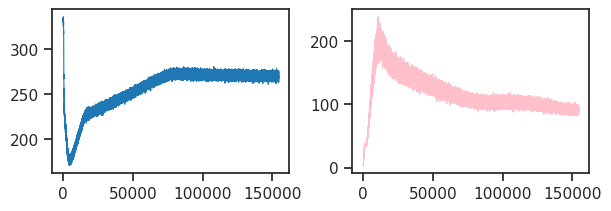

In [8]:
fig, axes = create_figure(1, 2)
axes[0].plot(list(tr.stats['loss'].keys()), list(tr.stats['loss'].values()), lw=0.8,)
axes[1].plot(list(tr.stats['grad'].keys()), list(tr.stats['grad'].values()), lw=0.8, color='pink');

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs(model_type, 'Kyoto32-jitter')

cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 16.0
cfg_tr['kl_anneal_portion'] = 0.3

cfg_tr['epochs']= 2000

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

In [6]:
print(vars(tr.model.cfg))

{
    'prior_log_dist': 'uniform',
    'clamp_prior': -4,
    'seq_len': 16,
    'tbptt_steps': 16,
    'n_iters_inner': 1,
    'n_iters_outer': 1,
    'sequences': {0: range(0, 16)},
    'dataset': 'Kyoto32-jitter',
    'dataset_name': 'Kyoto32',
    'feeder': 'jitter',
    'feeder_cfg': {'mode': 'crop', 'crop_size': 16, 'diff_coeff': 0.5, 'harmonic_strength': 0.01},
    'input_sz': (1, 16, 16),
    'shape': (-1, 1, 16, 16),
    'beta_inner': 1.0,
    'n_latents': [512],
    'inf_type': 'grad',
    'dec_type': 'lin',
    'clamp_u': 10.0,
    'clamp_du': 10.0,
    'init_dist': 'normal',
    'init_scale': 0.0001,
    'stochastic': True,
    'fit_prior': True,
    'track_stats': False,
    'seed': 0,
    'base_dir': '/home/hadi/Projects/PoissonVAE',
    'data_dir': '/home/hadi/Datasets',
    'runs_dir': '/home/hadi/Projects/PoissonVAE/runs/poisson_Kyoto32-jitter_t-16_z-[512]_cl-10,10_<grad|lin>',
    'mods_dir': '/home/hadi/Projects/PoissonVAE/models/poisson_Kyoto32-jitter_t-16_z-[512]_cl-10,10_<grad|lin>',
    'results_dir': '/home/hadi/Projects/PoissonVAE/results'
}

In [5]:
print(vars(tr.cfg))

{
    'lr': 0.002,
    'epochs': 2000,
    'batch_size': 200,
    'dataset_kws': None,
    'warm_restart': 0,
    'warmup_portion': 0.005,
    'optimizer': 'adamax_fast',
    'scheduler_type': 'cosine',
    'optimizer_kws': {'weight_decay': 0.0003, 'betas': (0.9, 0.999), 'eps': 1e-08},
    'scheduler_kws': {'T_max': 1990.0, 'eta_min': 1e-05},
    'ema_rate': None,
    'grad_clip': 500,
    'chkpt_freq': 50,
    'eval_freq': 20,
    'log_freq': 10,
    'kl_beta': 16.0,
    'kl_beta_min': 0.0001,
    'kl_balancer': None,
    'kl_time_adjuster': None,
    'kl_anneal_cycles': 0,
    'kl_anneal_portion': 0.3,
    'kl_const_portion': 0.001,
    'temp_anneal_portion': 0.5,
    'temp_anneal_type': 'lin',
    'temp_start': 1.0,
    'temp_stop': 0.01
}

In [8]:
print(tr.model.layer)

PoissonLayer(input_dim=256, latent_dim=512, temperature=1, beta_inner=1, eps=1)